In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

In [3]:
device = "cuda:1" if torch.cuda.is_available() else "cpu"
device

'cuda:1'

## Testing data loading

In [6]:
from dataset import SuctionGraspingDataset, data_transform, target_transform

In [7]:
dataset = SuctionGraspingDataset(
    data_path="../data",
    sample_list="../data/train-split.txt",
    transform=data_transform,
    target_transform=target_transform,
)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=False,
)

for color_batch, depth_batch, label_batch in loader:
    print(color_batch.shape)  # color_batch:  (B, 3, H, W)
    print(depth_batch.shape)  # depth_batch:  (B, 3, H, W)
    print(label_batch.shape)  # label_batch:  (B, H//8, W//8)
    break

torch.Size([4, 3, 480, 640])
torch.Size([4, 3, 480, 640])
torch.Size([4, 60, 80])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].


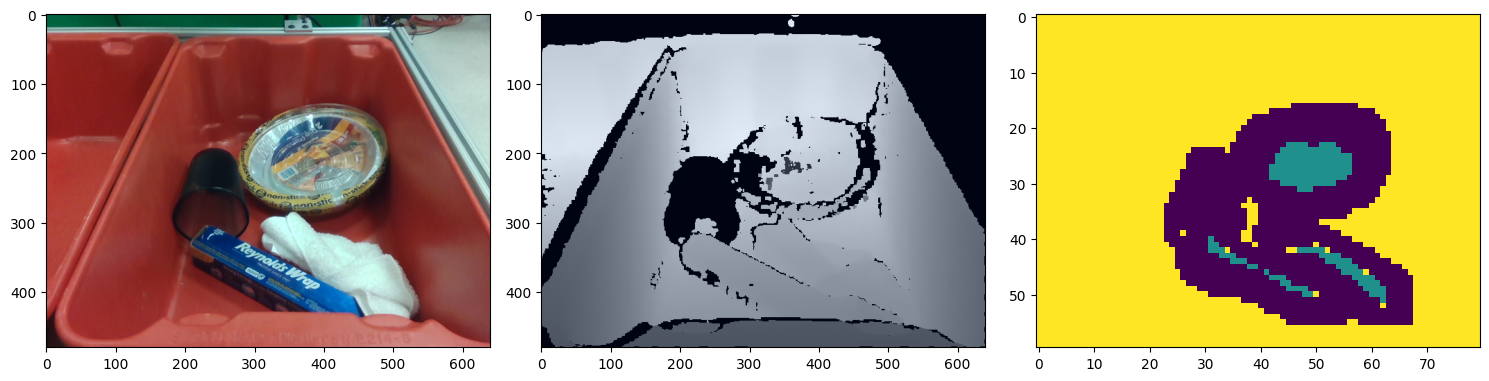

In [9]:
color_img_vis = torch.movedim(color_batch[0] * 0.229 + 0.485, 0, 2)
depth_img_vis = torch.movedim(depth_batch[0] * 0.229 + 0.485, 0, 2)
label_vis = label_batch[0] / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(color_img_vis)
axes[1].imshow(depth_img_vis)
axes[2].imshow(label_vis)
plt.tight_layout()
plt.show()

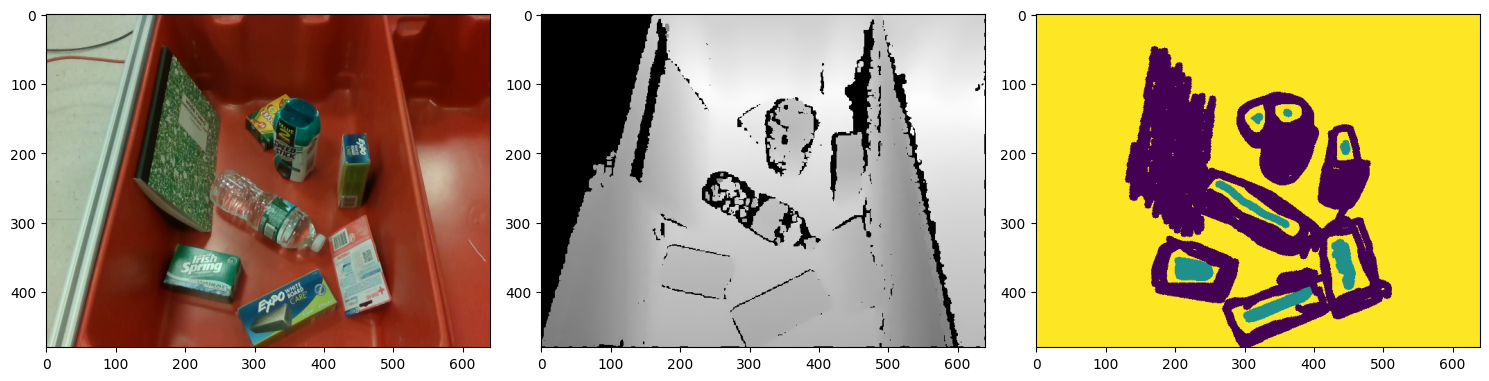

In [ ]:
raw_dataset = SuctionGraspingDataset(
    data_path="../data", sample_list="../data/train-split.txt", transform=None
)
color_img, depth_img, label_img = raw_dataset[4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(color_img)
axes[1].imshow(depth_img, cmap="gray")
axes[2].imshow(label_img)
plt.tight_layout()
plt.show()

## Testing the model

In [11]:
from model import RGBDResNet101
from metrics import masked_bce_loss

In [12]:
num_classes = 1
torch.cuda.empty_cache()
model = RGBDResNet101(num_classes=num_classes, pretrained=True).to(device)
model.eval();

In [13]:
with torch.no_grad():
    output = model(color_batch.to(device), depth_batch.to(device))
    loss = masked_bce_loss(output, label_batch.to(device))
print(f"Output shape: {output.shape}")
print(f"Labels shape: {label_batch.shape}")
print(f"Loss: {loss.cpu().item()}")

Output shape: torch.Size([4, 1, 60, 80])
Labels shape: torch.Size([4, 60, 80])
Loss: 0.5893346071243286


## Visualizing inference

In [ ]:
torch.cuda.empty_cache()
try:
    weights = "snapshots/snapshot-5000.pt"
    model = RGBDResNet101(num_classes=1, pretrained=False)
    checkpoint = torch.load(weights, map_location=device, weights_only=True)
    if "optimizer" in checkpoint and "model" in checkpoint:
        checkpoint = checkpoint["model"]
    model.load_state_dict(checkpoint)
except Exception:
    print("Couldn't load weights. Using weights from pretraining on ImageNet")
    model = RGBDResNet101(num_classes=1, pretrained=True)
model = model.to(device).eval()

In [17]:
color_img, depth_img, label_img = raw_dataset[4]
color, depth = data_transform(color_img, depth_img)

with torch.no_grad():
    color = color[None].to(device)
    depth = depth[None].to(device)
    output = F.sigmoid(model(color, depth))

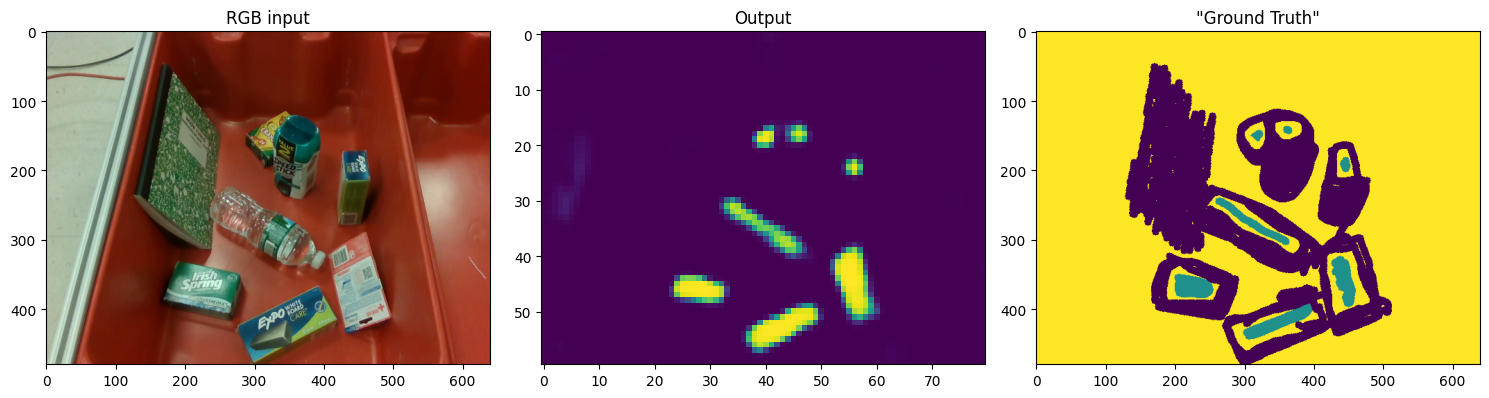

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title("RGB input")
axes[0].imshow(color_img)
axes[1].set_title("Output")
axes[1].imshow(output[0, 0].cpu().numpy())
axes[2].set_title('"Ground Truth"')
axes[2].imshow(label_img)
plt.tight_layout()
plt.show()

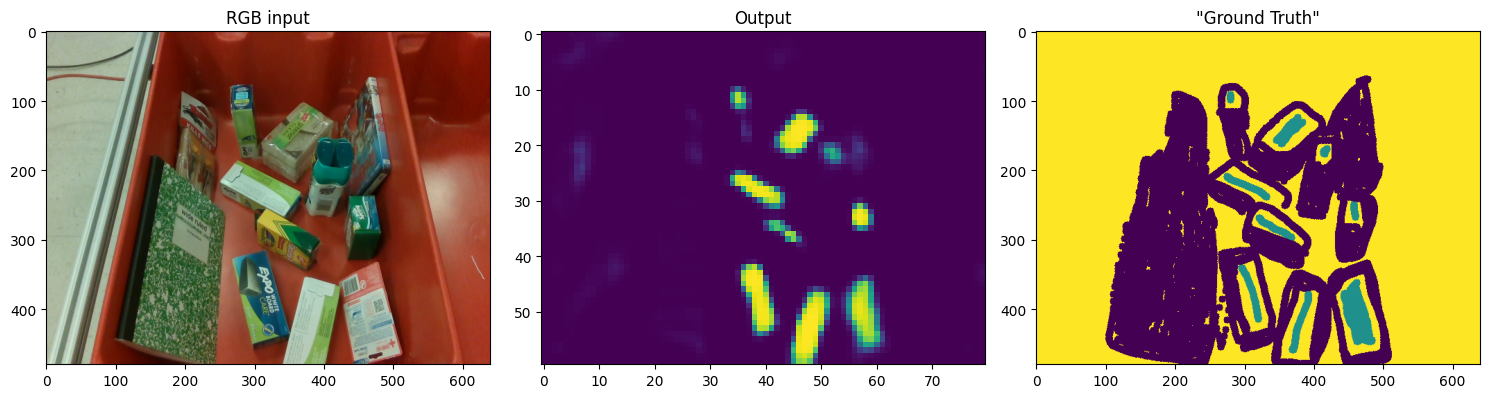

In [ ]:
dataset = SuctionGraspingDataset(
    data_path="../data", sample_list="../data/test-split.txt"
)
color_img, depth_img, label_img = dataset[4]
color, depth = data_transform(color_img, depth_img)

with torch.no_grad():
    color = color[None].to(device)
    depth = depth[None].to(device)
    output = F.sigmoid(model(color, depth))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title("RGB input")
axes[0].imshow(color_img)
axes[1].set_title("Output")
axes[1].imshow(output[0, 0].cpu().numpy())
axes[2].set_title('"Ground Truth"')
axes[2].imshow(label_img)
plt.tight_layout()
plt.show()

## Full inference pipeline

In [4]:
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [5]:
from model import load_model
from postprocess import postprocess_affordances
from dataset import load_inference_sample

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Visualisation functions

In [6]:
def overlay_affordance(rgb_img, affordance, alpha=0.5, cmap='jet'):
    """Overlay the affordance map as a heatmap on the RGB image."""
    # Normalise affordance to [0,1]
    a = affordance.copy()
    a[a >= 1.0] = 0.9999
    a[a < 0.0] = 0.0
    colored = plt.get_cmap(cmap)(a)[:, :, :3]  # ignore alpha channel of colormap
    overlay = rgb_img * (1 - alpha) + colored * alpha
    return np.clip(overlay, 0, 1)

def generate_color_wheel(size=256):
    """Generate a color-wheel image for the normals visualization."""
    xs = np.linspace(-1.0, 1.0, size)
    ys = np.linspace(-1.0, 1.0, size)
    xv, yv = np.meshgrid(xs, ys)
    r2 = xv**2 + yv**2

    mask = r2 <= 1.0
    nx = np.zeros_like(xv)
    ny = np.zeros_like(yv)
    nz = np.zeros_like(xv)

    nx[mask] = xv[mask]
    ny[mask] = yv[mask]
    nz[mask] = -np.sqrt(np.clip(1.0 - r2[mask], 0.0, 1.0))  # camera-facing hemisphere (nz<=0)

    normals = np.stack([nx, ny, nz], axis=-1)
    normals[~mask] = 0
    return (normals + 1.0) / 2.0  # map from [-1,1] -> [0,1]

def show_images(rgb, affordance, title_afford, normals=None, title_normals="Surface Normals"):
    """Display RGB, affordance overlay, and optionally normals."""
    fig, axes = plt.subplots(1, 4 if normals is not None else 2, figsize=(18, 6))
    axes[0].imshow(rgb)
    axes[0].set_title("Input RGB")
    axes[0].axis('off')

    overlay = overlay_affordance(rgb, affordance)
    axes[1].imshow(overlay)
    axes[1].set_title(title_afford)
    axes[1].axis('off')

    if normals is not None:
        # Normal vectors are in range [-1, 1] (camera coordinates). Map to [0,1] for display.
        normals_disp = (normals + 1) / 2.0
        axes[2].imshow(normals_disp)
        axes[2].set_title(title_normals)
        axes[2].axis('off')

        color_wheel = generate_color_wheel()
        axes[3].imshow(color_wheel)
        axes[3].set_title("Color legend")
        axes[3].axis('off')
    plt.tight_layout()
    plt.show()

Configuration:

In [7]:
# rgb_path = "demo/test-image.color.png"
# depth_path = "demo/test-image.depth.png"
# bg_rgb_path = "demo/test-background.color.png"
# bg_depth_path = "demo/test-background.depth.png"
# intrinsics_path = "demo/test-camera-intrinsics.txt"

image_name = "000024-0"
rgb_path = f"../data/color-input/{image_name}.png"
depth_path = f"../data/depth-input/{image_name}.png"
bg_rgb_path = f"../data/color-background/{image_name}.png"
bg_depth_path = f"../data/depth-background/{image_name}.png"
intrinsics_path = f"../data/camera-intrinsics/{image_name}.txt"

weights_path = "weights/default_weights.pt"

postprocess_kwargs = {
    "color_thresh": 0.3,
    "depth_thresh": 0.02,
    "normals_knn": 50,
    "normals_window": 25,
    "suction_score_thresh": 0.1,
}

In [ ]:
sample = load_inference_sample(rgb_path, depth_path, bg_rgb_path, bg_depth_path, intrinsics_path)
model = load_model(weights_path, device)
model.eval()

input_h, input_w, _ = sample.color_raw.shape
print(f"Original image size: {input_w}x{input_h}")

Loading model from weights/default_weights.pt
Original image size: 640x480


Running the model:

Network output shape: (60, 80)


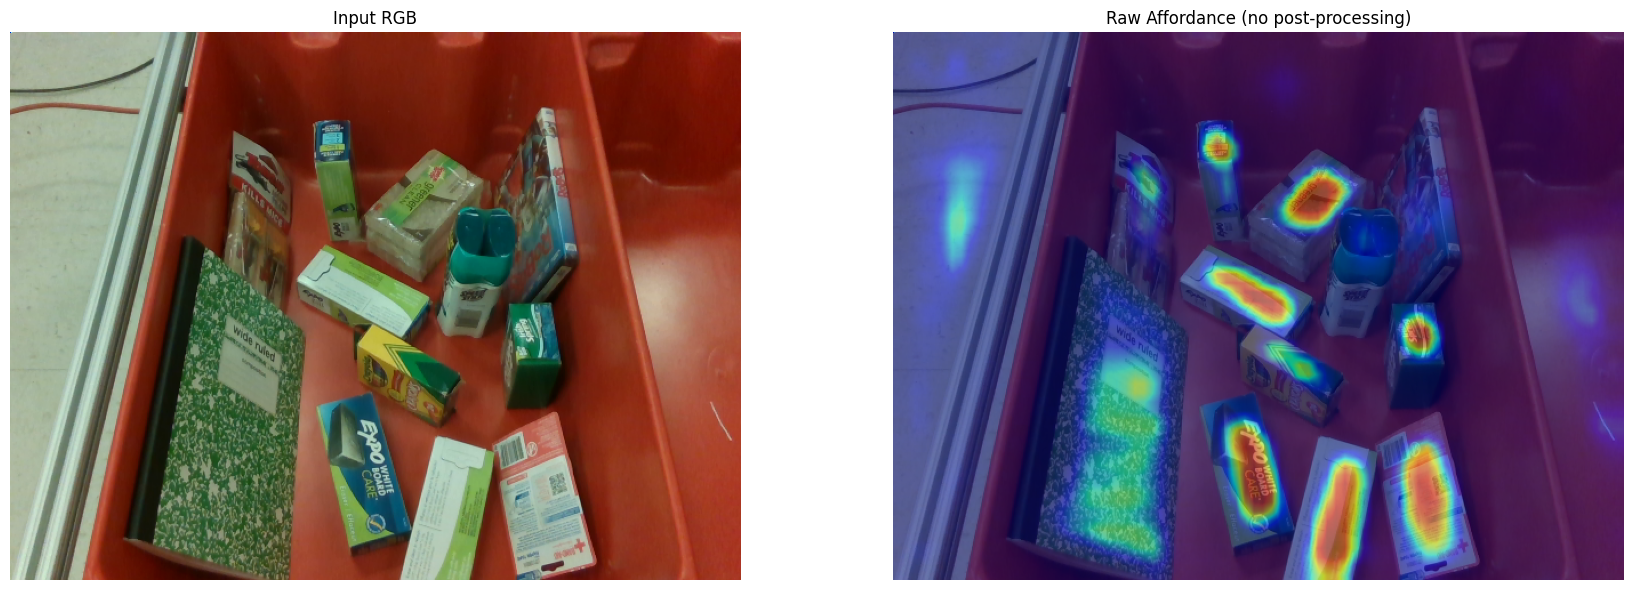

In [9]:
with torch.no_grad():
    color = sample.color[None].to(device)
    depth = sample.depth[None].to(device)
    output = F.sigmoid(model(color, depth))

# output shape is (1, 1, H_out, W_out) where H_out = H/8, W_out = W/8
afford_map_small = output.cpu().squeeze().numpy()
print(f"Network output shape: {afford_map_small.shape}")

# Resize to original image size using bilinear interpolation
afford_raw = np.array(
    Image.fromarray((afford_map_small * 255).astype(np.uint8))
    .resize((input_w, input_h), Image.BILINEAR)
) / 255.0

# Visualise raw affordance
show_images(sample.color_raw, afford_raw, "Raw Affordance (no post-processing)")

Post-processing

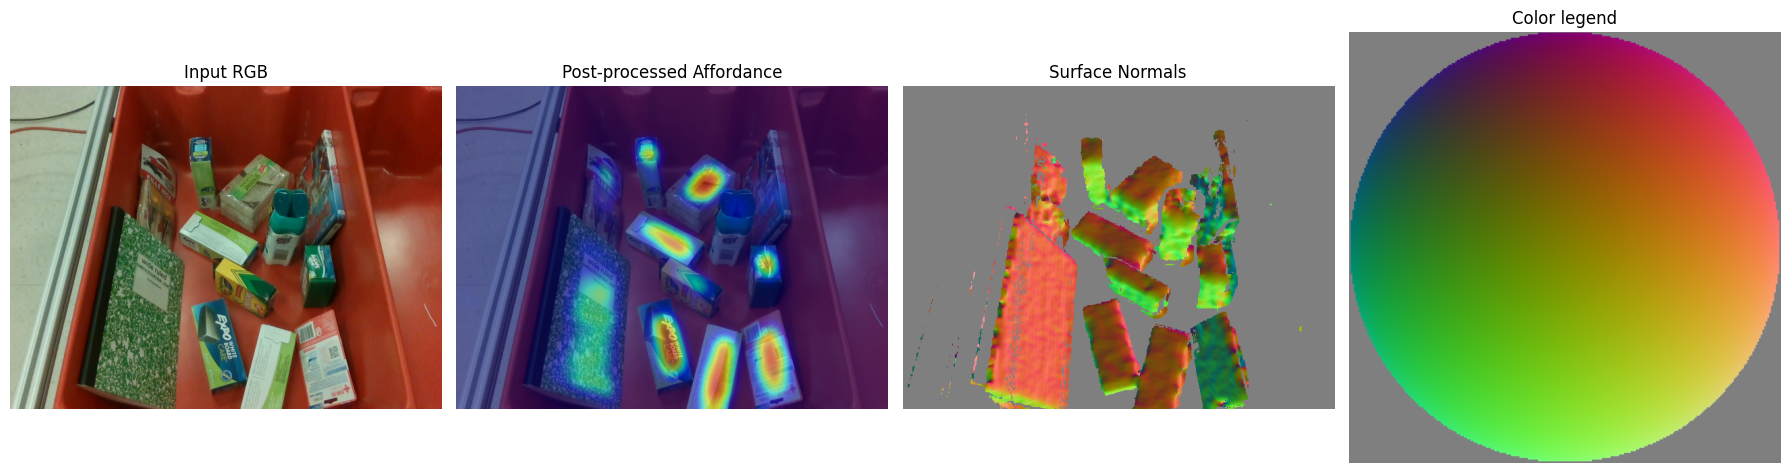

In [10]:
afford_processed, normals = postprocess_affordances(
    affordance_map=afford_raw.copy(),   # function modifies in‑place, so copy
    input_color=sample.color_raw,
    input_depth=sample.depth_raw,
    background_color=sample.bg_color_raw,
    background_depth=sample.bg_depth_raw,
    camera_intrinsics=sample.intrinsics,
    **postprocess_kwargs,
)
smooth_afford = gaussian_filter(afford_processed, sigma=7)
show_images(sample.color_raw, smooth_afford, "Post-processed Affordance", normals)

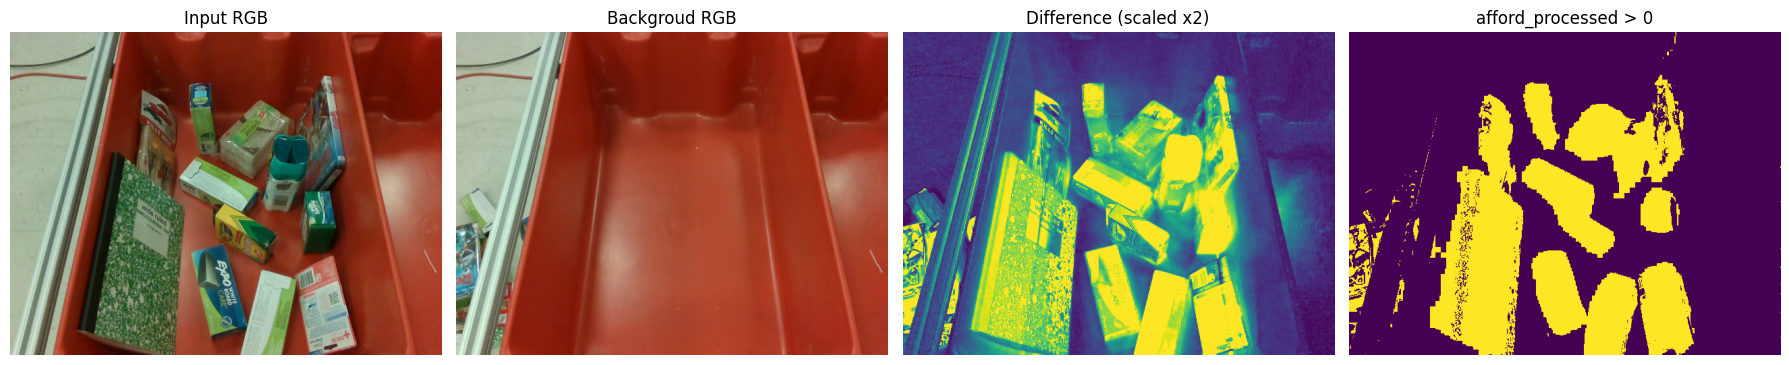

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes[0].imshow(sample.color_raw)
axes[0].set_title("Input RGB")
axes[0].axis('off')

axes[1].imshow(sample.bg_color_raw)
axes[1].set_title("Backgroud RGB")
axes[1].axis('off')

diff = np.sum((sample.color_raw - sample.bg_color_raw)**2, axis=2)**0.5
axes[2].imshow(np.clip(diff * 2, 0, 1))
axes[2].set_title("Difference (scaled x2)")
axes[2].axis('off')

axes[3].imshow(afford_processed > 0)
axes[3].set_title("afford_processed > 0")
axes[3].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Image.fromarray((afford_raw * 255).astype(np.uint8), mode='L').save("result_raw.png")
# Image.fromarray((afford_processed * 255).astype(np.uint8), mode='L').save("result_processed.png")

## Model summary

In [ ]:
class ResNet2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = RGBDResNet101(num_classes=3)

    def forward(self, x):
        return self.model(x[0], x[1])

In [19]:
from torchinfo import summary

summary(ResNet2(), input_size=(2, 4, 3, 480, 640))

Layer (type:depth-idx)                             Output Shape              Param #
ResNet2                                            [4, 3, 60, 80]            --
├─RGBDResNet101: 1-1                               [4, 3, 60, 80]            --
│    └─Sequential: 2-1                             [4, 1024, 30, 40]         --
│    │    └─Conv2d: 3-1                            [4, 64, 240, 320]         9,408
│    │    └─BatchNorm2d: 3-2                       [4, 64, 240, 320]         (128)
│    │    └─ReLU: 3-3                              [4, 64, 240, 320]         --
│    │    └─MaxPool2d: 3-4                         [4, 64, 120, 160]         --
│    │    └─Sequential: 3-5                        [4, 256, 120, 160]        215,808
│    │    └─Sequential: 3-6                        [4, 512, 60, 80]          1,219,584
│    │    └─Sequential: 3-7                        [4, 1024, 30, 40]         26,090,496
│    └─Sequential: 2-2                             [4, 1024, 30, 40]         --
│    │   